In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv('train.csv')
df.head()

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,State,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales
0,1,CA-2017-152156,08/11/2017,11/11/2017,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,Kentucky,42420.0,South,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.9600
1,2,CA-2017-152156,08/11/2017,11/11/2017,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,Kentucky,42420.0,South,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400
2,3,CA-2017-138688,12/06/2017,16/06/2017,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,California,90036.0,West,OFF-LA-10000240,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.6200
3,4,US-2016-108966,11/10/2016,18/10/2016,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,Florida,33311.0,South,FUR-TA-10000577,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,957.5775
4,5,US-2016-108966,11/10/2016,18/10/2016,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,Florida,33311.0,South,OFF-ST-10000760,Office Supplies,Storage,Eldon Fold 'N Roll Cart System,22.3680


In [2]:
print("Shape:", df.shape)
df.info()

Shape: (9800, 18)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9800 entries, 0 to 9799
Data columns (total 18 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Row ID         9800 non-null   int64  
 1   Order ID       9800 non-null   object 
 2   Order Date     9800 non-null   object 
 3   Ship Date      9800 non-null   object 
 4   Ship Mode      9800 non-null   object 
 5   Customer ID    9800 non-null   object 
 6   Customer Name  9800 non-null   object 
 7   Segment        9800 non-null   object 
 8   Country        9800 non-null   object 
 9   City           9800 non-null   object 
 10  State          9800 non-null   object 
 11  Postal Code    9789 non-null   float64
 12  Region         9800 non-null   object 
 13  Product ID     9800 non-null   object 
 14  Category       9800 non-null   object 
 15  Sub-Category   9800 non-null   object 
 16  Product Name   9800 non-null   object 
 17  Sales          9800 non-null   flo

In [3]:
print(df.isnull().sum())

Row ID            0
Order ID          0
Order Date        0
Ship Date         0
Ship Mode         0
Customer ID       0
Customer Name     0
Segment           0
Country           0
City              0
State             0
Postal Code      11
Region            0
Product ID        0
Category          0
Sub-Category      0
Product Name      0
Sales             0
dtype: int64


In [4]:
df['Order Date'] = pd.to_datetime(df['Order Date'], dayfirst=True)
print("Date range:", df['Order Date'].min(), "to", df['Order Date'].max())

Date range: 2015-01-03 00:00:00 to 2018-12-30 00:00:00


In [5]:
monthly_sales = df.set_index('Order Date')['Sales'].resample('ME').sum()
monthly_sales.head(10)

Order Date
2015-01-31    14205.7070
2015-02-28     4519.8920
2015-03-31    55205.7970
2015-04-30    27906.8550
2015-05-31    23644.3030
2015-06-30    34322.9356
2015-07-31    33781.5430
2015-08-31    27117.5365
2015-09-30    81623.5268
2015-10-31    31453.3930
Freq: ME, Name: Sales, dtype: float64

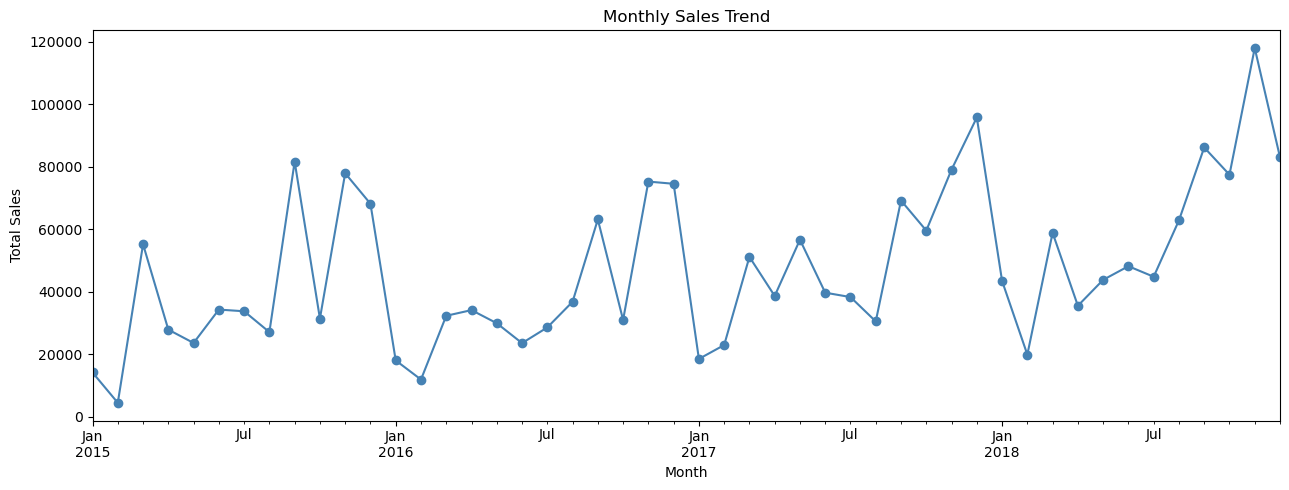

In [6]:
plt.figure(figsize=(13,5))
monthly_sales.plot(marker='o', color='steelblue')
plt.title('Monthly Sales Trend')
plt.xlabel('Month')
plt.ylabel('Total Sales')
plt.tight_layout()
plt.show()

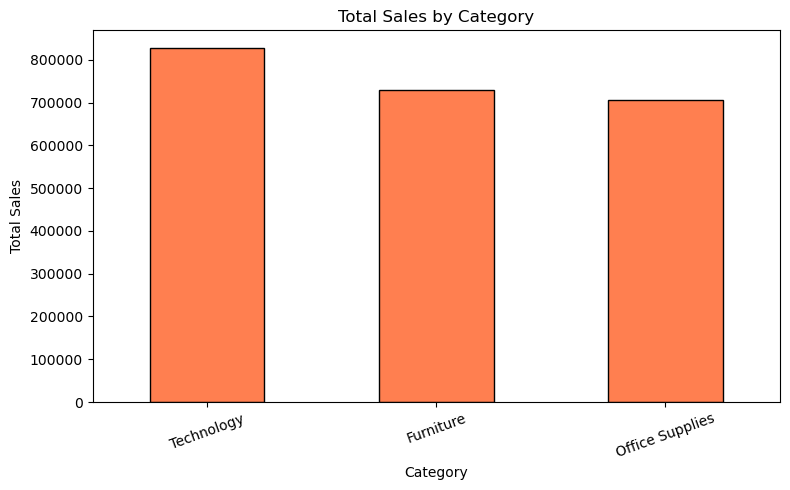

In [7]:
category_sales = df.groupby('Category')['Sales'].sum().sort_values(ascending=False)

plt.figure(figsize=(8,5))
category_sales.plot(kind='bar', color='coral', edgecolor='black')
plt.title('Total Sales by Category')
plt.xlabel('Category')
plt.ylabel('Total Sales')
plt.xticks(rotation=20)
plt.tight_layout()
plt.show()

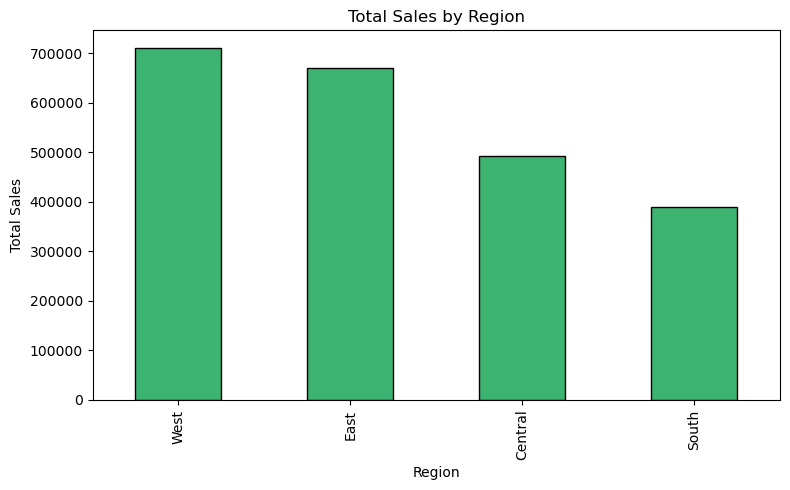

In [8]:
region_sales = df.groupby('Region')['Sales'].sum().sort_values(ascending=False)

plt.figure(figsize=(8,5))
region_sales.plot(kind='bar', color='mediumseagreen', edgecolor='black')
plt.title('Total Sales by Region')
plt.xlabel('Region')
plt.ylabel('Total Sales')
plt.tight_layout()
plt.show()

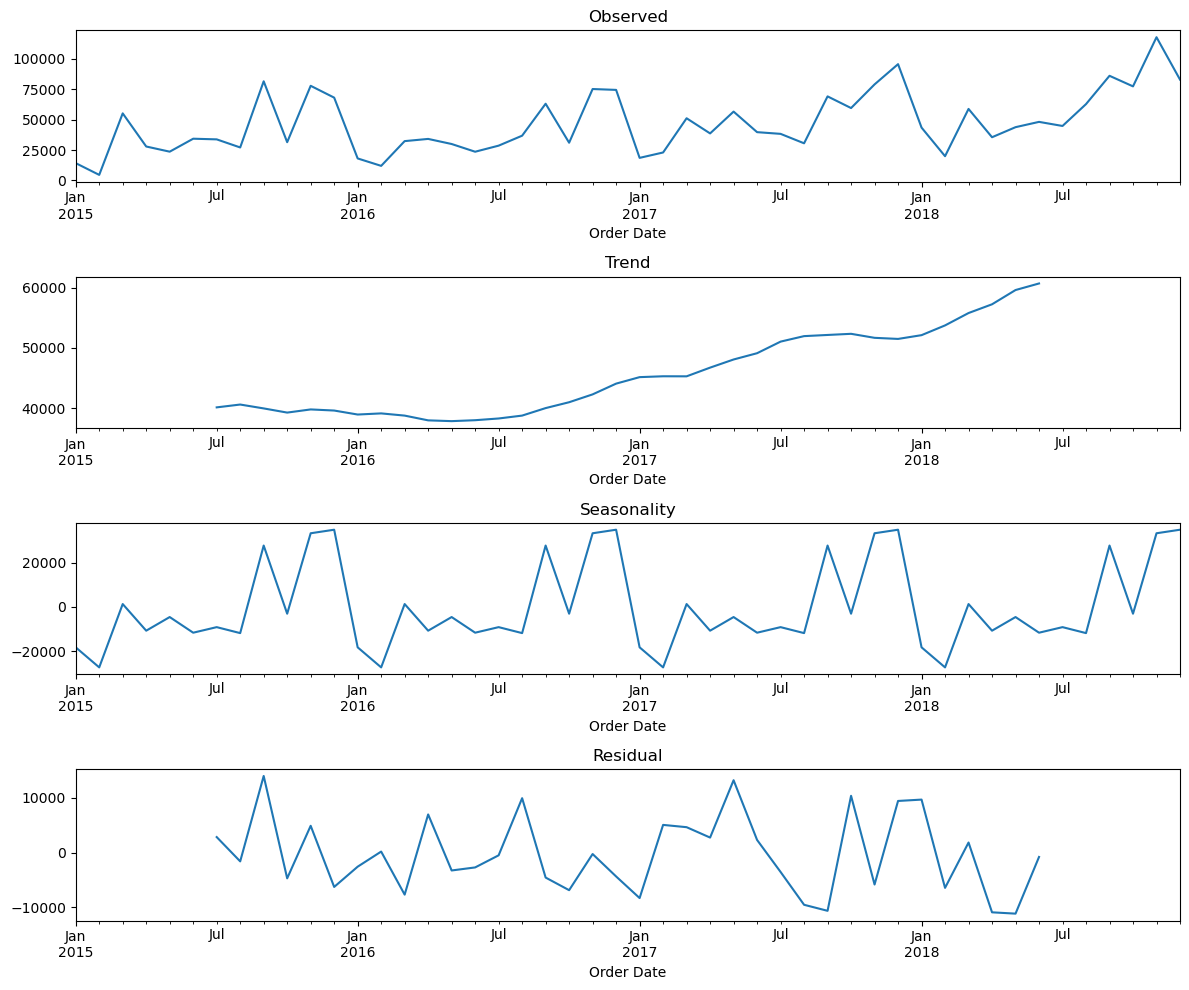

In [9]:
from statsmodels.tsa.seasonal import seasonal_decompose

decomposition = seasonal_decompose(monthly_sales, model='additive', period=12)

fig, axes = plt.subplots(4, 1, figsize=(12,10))
decomposition.observed.plot(ax=axes[0], title='Observed')
decomposition.trend.plot(ax=axes[1], title='Trend')
decomposition.seasonal.plot(ax=axes[2], title='Seasonality')
decomposition.resid.plot(ax=axes[3], title='Residual')
plt.tight_layout()
plt.show()

In [10]:
!pip install statsmodels

In [11]:
train = monthly_sales[:-6]
test = monthly_sales[-6:]

print("Train months:", len(train))
print("Test months:", len(test))

Train months: 42
Test months: 6


In [12]:
naive_forecast = pd.Series([train.iloc[-1]] * len(test), index=test.index)
naive_forecast

Order Date
2018-07-31    48190.7277
2018-08-31    48190.7277
2018-09-30    48190.7277
2018-10-31    48190.7277
2018-11-30    48190.7277
2018-12-31    48190.7277
Freq: ME, dtype: float64

In [13]:
from statsmodels.tsa.holtwinters import ExponentialSmoothing

hw_model = ExponentialSmoothing(train, trend='add', seasonal='add', seasonal_periods=12)
hw_fit = hw_model.fit()

hw_forecast = hw_fit.forecast(len(test))
hw_forecast

2018-07-31    44195.191721
2018-08-31    42519.191239
2018-09-30    82474.938795
2018-10-31    50660.321380
2018-11-30    88330.224917
2018-12-31    89481.353642
Freq: ME, dtype: float64

In [14]:
from sklearn.metrics import mean_absolute_error, mean_squared_error

def evaluate(name, actual, predicted):
    mae = mean_absolute_error(actual, predicted)
    rmse = np.sqrt(mean_squared_error(actual, predicted))
    print(f"=== {name} ===")
    print(f"MAE:  {mae:,.2f}")
    print(f"RMSE: {rmse:,.2f}\n")

evaluate("Naive Baseline", test, naive_forecast)
evaluate("Holt-Winters", test, hw_forecast)

=== Naive Baseline ===
MAE:  31,636.57
RMSE: 37,862.67

=== Holt-Winters ===
MAE:  14,578.87
RMSE: 18,540.96



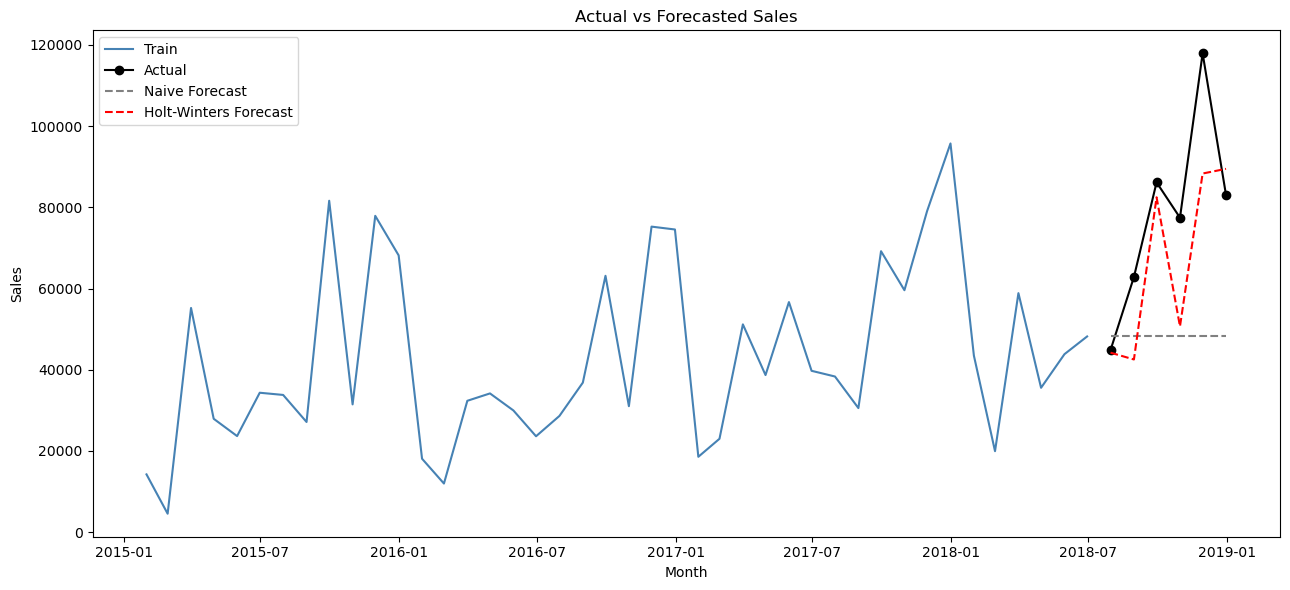

In [15]:
plt.figure(figsize=(13,6))
plt.plot(train.index, train, label='Train', color='steelblue')
plt.plot(test.index, test, label='Actual', color='black', marker='o')
plt.plot(test.index, naive_forecast, label='Naive Forecast', linestyle='--', color='gray')
plt.plot(test.index, hw_forecast, label='Holt-Winters Forecast', linestyle='--', color='red')
plt.title('Actual vs Forecasted Sales')
plt.xlabel('Month')
plt.ylabel('Sales')
plt.legend()
plt.tight_layout()
plt.show()

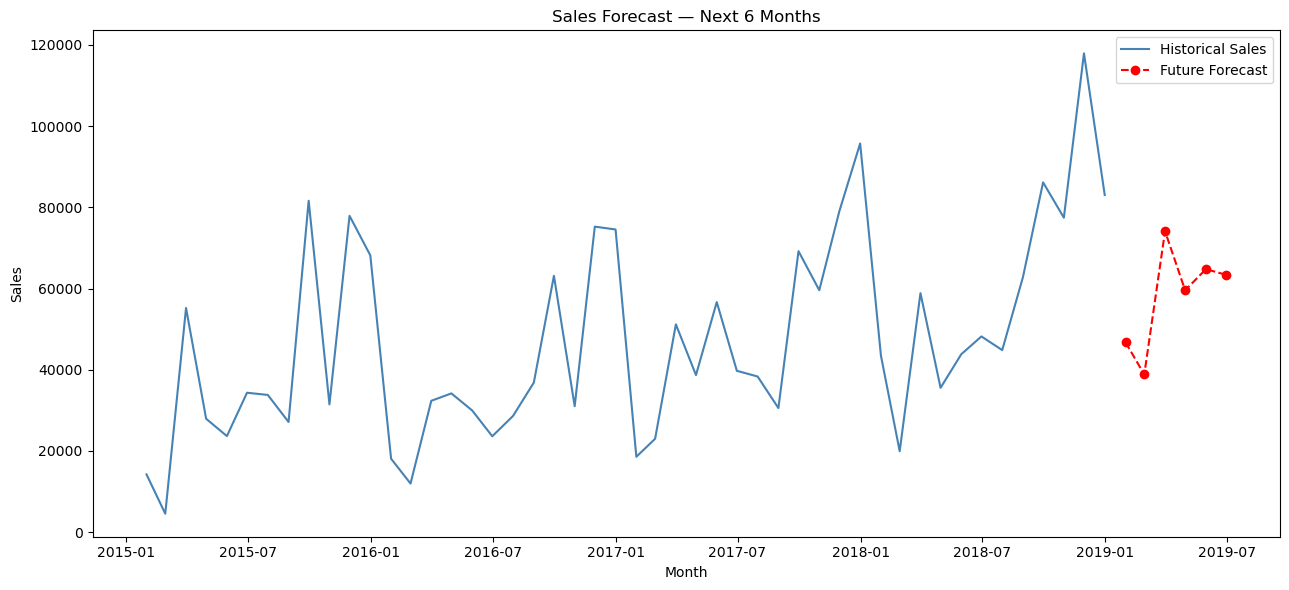

2019-01-31    46757.254780
2019-02-28    38817.617203
2019-03-31    74121.205289
2019-04-30    59560.754479
2019-05-31    64770.575989
2019-06-30    63379.518182
Freq: ME, dtype: float64


In [16]:
final_model = ExponentialSmoothing(monthly_sales, trend='add', seasonal='add', seasonal_periods=12)
final_fit = final_model.fit()

future_forecast = final_fit.forecast(6)

plt.figure(figsize=(13,6))
plt.plot(monthly_sales.index, monthly_sales, label='Historical Sales', color='steelblue')
plt.plot(future_forecast.index, future_forecast, label='Future Forecast', linestyle='--', color='red', marker='o')
plt.title('Sales Forecast — Next 6 Months')
plt.xlabel('Month')
plt.ylabel('Sales')
plt.legend()
plt.tight_layout()
plt.show()

print(future_forecast)

In [17]:
monthly_sales.to_csv('monthly_sales_aggregated.csv', header=['Sales'])
print("Monthly sales data saved as 'monthly_sales_aggregated.csv'")

Monthly sales data saved as 'monthly_sales_aggregated.csv'
